In [1]:
import sys
sys.path.append(r"cf-shap-main/src") 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
from shap import Explanation, plots

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from cfshap import *
from cfshap.utils import attrdict
from cfshap.utils.preprocessing import EfficientQuantileTransformer
from cfshap.counterfactuals import KNNCounterfactuals
from cfshap.attribution import TreeExplainer, CompositeExplainer
from cfshap.trend import TrendEstimator

## Dataset & pre-processing

In [2]:
# !pip install ucimlrepo

# fetch the dataset from the UCI repository to view variable information
from ucimlrepo import fetch_ucirepo 
print(fetch_ucirepo(id=144).variables)

           name     role         type     demographic  \
0    Attribute1  Feature  Categorical            None   
1    Attribute2  Feature      Integer            None   
2    Attribute3  Feature  Categorical            None   
3    Attribute4  Feature  Categorical            None   
4    Attribute5  Feature      Integer            None   
5    Attribute6  Feature  Categorical            None   
6    Attribute7  Feature  Categorical           Other   
7    Attribute8  Feature      Integer            None   
8    Attribute9  Feature  Categorical  Marital Status   
9   Attribute10  Feature  Categorical            None   
10  Attribute11  Feature      Integer            None   
11  Attribute12  Feature  Categorical            None   
12  Attribute13  Feature      Integer             Age   
13  Attribute14  Feature  Categorical            None   
14  Attribute15  Feature  Categorical           Other   
15  Attribute16  Feature      Integer            None   
16  Attribute17  Feature  Categ

In [3]:
# import the dataset
df = pd.read_csv("german.data", sep='\s+', header=None)

# view raw data
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
# dataset preprocessing

# (1) rename columns to have feature names instead of integers
df.columns = [
    "Status checking account", "Duration", "Credit history", "Purpose", "Credit amount",
    "Savings/bonds", "Employment since", "Installment rate", "Personal status", "Other debtors",
    "Residence since", "Property", "Age", "Other installment plans", "Housing",
    "Existing credits", "Job", "People liable", "Telephone", "Foreign worker", "CLASS"
]

# (2) change the categorical features to be numeric
# note: see the 'german.doc' word file for the meanings of the categories
mapping = {
    # feature 1: Status checking account
    'A11': 1, 'A12': 2, 'A13': 3, 'A14': 4,
    # feature 3: Credit history
    'A30': 1, 'A31': 2, 'A32': 3, 'A33': 4, 'A34': 5,
    # feature 4: Purpose
    'A40': 1, 'A41': 2, 'A42': 3, 'A43': 4, 'A44': 5, 'A45': 6,
    'A46': 7, 'A47': 8, 'A48': 9, 'A49': 10, 'A410': 11,
    # feature 6: Savings/bonds
    'A61': 1, 'A62': 2, 'A63': 3, 'A64': 4, 'A65': 5,
    # feature 7: Employment since
    'A71': 1, 'A72': 2, 'A73': 3, 'A74': 4, 'A75': 5,
    # feature 9: Personal status 
    'A91': 1, 'A92': 2, 'A93': 3, 'A94': 4, 'A95': 5,
    # feature 10: Other debtors 
    'A101': 1, 'A102': 2, 'A103': 3,
    # feature 12: Property
    'A121': 1, 'A122': 2, 'A123': 3, 'A124': 4,
    # feature 14: Other installment plans
    'A141': 1, 'A142': 2, 'A143': 3,
    # feature 15: Housing
    'A151': 1, 'A152': 2, 'A153': 3,
    # feature 17: Job
    'A171': 1, 'A172': 2, 'A173': 3, 'A174': 4,
    # feature 19: Telephone
    'A191': 0, 'A192': 1,
    # feature 20: Foreign worker
    'A201': 1, 'A202': 0
}
df = df.replace(mapping)

# (3) remove the features that are non-changeable and personal
non_changeable= [
   "Personal status", "Age", "Foreign worker"
]
df = df.drop(columns=non_changeable)

df.head()

,Status checking account,Duration,Credit history,Purpose,Credit amount,Savings/bonds,Employment since,Installment rate,Other debtors,Residence since,Property,Other installment plans,Housing,Existing credits,Job,People liable,Telephone,CLASS
0,1,6,5,4,1169,5,5,4,1,4,1,3,2,2,3,1,1,1
1,2,48,3,4,5951,1,3,2,1,2,1,3,2,1,3,1,0,2
2,4,12,5,7,2096,1,4,2,1,3,1,3,2,1,2,2,0,1
3,1,42,3,3,7882,1,4,2,3,4,2,3,3,1,3,2,0,1
4,1,24,4,1,4870,1,3,3,1,4,4,3,3,2,3,2,0,2


## Creating the model


In [5]:
# the features (X) are all columns except CLASS
X = df.drop(columns=["CLASS"])
feature_names = df.drop(columns=["CLASS"]).columns
# make sure it's a numpy array
X = X.values if hasattr(X,"values") else np.array(X)

# the target (y) is the CLASS column
# this is turned into a binary where: CLASS=GOOD(1) -> 1 and CLASS=BAD(2) -> 0
y = (df["CLASS"] == 1).astype(int)  

# the model used is a random forest classifier
model = RandomForestClassifier(
    n_estimators=100,  
    max_depth=None,     
    random_state=42     
)
model.fit(X,y.values.ravel())
y_pred = model.predict(X)

## 1. SHAP Explanations

In [6]:
shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer.shap_values(X)

## 2. CF-SHAP Explanations

The following code was adapted from the CF-SHAP github repository (https://github.com/ealbini/CF-SHAP)

Albini, E., Long, J., Dervovic, D., & Magazzeni, D. (2022). *Counterfactual Shapley Additive Explanations.*  
Proceedings of the ACM Conference on Fairness, Accountability, and Transparency (FAccT '22).  
https://doi.org/10.1145/3531146.3533168

In [7]:
# setting up the explainers
MAX_SAMPLES = 10000

# we will need a scaler in the input space for the counterfactual generator
scaler = EfficientQuantileTransformer()
scaler.fit(X)

# background/counterfactuals generator
background_generator = KNNCounterfactuals(
    model=model,
    X=X,
    n_neighbors=100,
    distance='cityblock',
    scaler=scaler,
    max_samples=MAX_SAMPLES,
)

# we will need a trend estimator for the attribution estimator
trend_estimator = TrendEstimator(strategy='mean')

# feature importance estimator
importance_estimator = TreeExplainer(
    model,
    data=None,
    trend_estimator=trend_estimator,
    max_samples=MAX_SAMPLES,
)

# setup the explainer
cfshap_explainer = CompositeExplainer(
    background_generator,
    importance_estimator,
)

explanations = cfshap_explainer(X)
list(explanations.keys())

1000it [00:45, 22.04it/s]


['backgrounds', 'values', 'trends']

The `explanations` object contains:
- The (Counterfactual) SHAP values (`explanations.values`)
- The induced trends from the counterfactuals (`explanations.trends`).
- The counterfactuals that have been used as background for each of the query instances (`explanations.backgrounds`)

## Comparing results

### 1. Shapley values

In [8]:
# SHAP
pd.DataFrame(shap_values[1], columns=feature_names).head()

,Status checking account,Duration,Credit history,Purpose,Credit amount,Savings/bonds,Employment since,Installment rate,Other debtors,Residence since,Property,Other installment plans,Housing,Existing credits,Job,People liable,Telephone
0,-0.086000,0.096265,0.068737,0.016327,0.016046,0.054932,0.028400,-0.007065,-0.002377,0.006209,0.032284,0.011619,0.010976,0.006729,-0.002278,0.002059,0.007547
1,-0.122116,-0.283967,-0.020271,-0.014298,-0.034582,-0.072440,-0.023248,0.016431,-0.004928,-0.019988,-0.001647,0.002236,-0.001311,-0.003873,-0.015687,-0.008320,-0.001582
2,0.089352,0.046620,0.047913,-0.021044,0.015239,-0.017468,0.037182,0.018955,0.000821,0.002053,0.015015,0.019973,0.008266,0.002072,0.003893,-0.002966,-0.005464
3,-0.112064,-0.037096,0.005741,0.023532,-0.029727,-0.015020,0.026982,0.047206,0.047004,0.011503,0.019819,0.012431,0.010867,0.001909,-0.006026,0.039562,0.003786
4,-0.170550,-0.041562,-0.008766,-0.066660,-0.005198,-0.033788,-0.031507,-0.038979,-0.005063,-0.015128,-0.070123,-0.000661,-0.023118,-0.016659,-0.014878,-0.013899,-0.023050


In [9]:
# CF-SHAP
pd.DataFrame(explanations.values, columns=feature_names).head()

,Status checking account,Duration,Credit history,Purpose,Credit amount,Savings/bonds,Employment since,Installment rate,Other debtors,Residence since,Property,Other installment plans,Housing,Existing credits,Job,People liable,Telephone
0,-0.001921,0.166534,0.112530,0.042182,0.054503,0.099740,0.060363,0.008105,0.001485,0.027923,0.063219,0.023684,0.017076,0.025200,0.005812,0.005024,0.027243
1,-0.145766,-0.357774,-0.016882,-0.024795,-0.065470,-0.037298,-0.023901,-0.006371,-0.012483,-0.027577,-0.034396,-0.003927,-0.005782,-0.004409,-0.015074,-0.002695,-0.001501
2,0.169341,0.098305,0.091001,0.012610,0.060560,0.006979,0.073476,0.042697,0.004877,0.024905,0.040572,0.034975,0.011007,0.008005,0.022032,0.012354,0.002003
3,-0.004670,0.040867,0.028130,0.034547,0.048246,0.006963,0.043599,0.073247,0.102651,0.023646,0.047079,0.012399,0.031085,0.005076,0.000775,0.078260,0.011402
4,-0.145264,-0.050683,-0.063943,-0.083761,-0.044353,-0.025641,-0.047381,-0.086349,-0.005065,-0.017936,-0.069037,-0.004892,-0.029215,-0.022309,-0.014520,-0.024742,-0.027208


### 2. Global explanation (most important features overall)

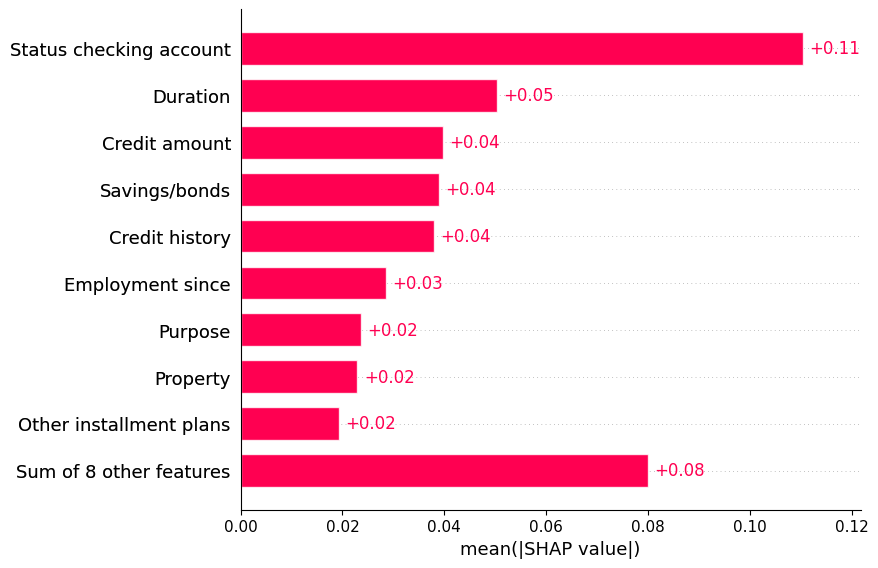

In [10]:
# SHAP
global_explanation = Explanation(
    values=shap_values[1],
    feature_names=feature_names,
    data=X
)

shap.plots.bar(global_explanation)

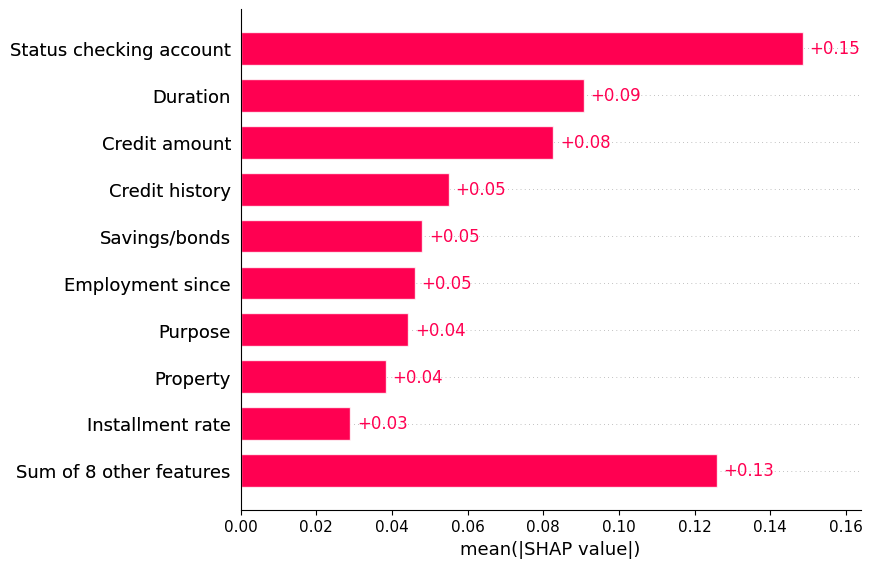

In [11]:
# CF-SHAP
global_explanation = Explanation(
    values=explanations.values,
    feature_names=feature_names,
    data=X
)

shap.plots.bar(global_explanation)

### Example of a rejected application

In [12]:
# find all the rejected applications
rejected = np.where(y == 0)[0]
print("Num. rejected applications:", len(rejected))

# we will use the first rejected application as an example
i = rejected[0]

Num. rejected applications: 300


In [13]:
# top 3 features and their shapley values for the first rejected application
def get_top(values, k):
    idx = np.argsort(np.abs(values))[-k:]
    return idx[np.argsort(np.abs(values[idx]))[::-1]]

# SHAP
top_3_shap = get_top(shap_values[1][i],3)  # top 3 features
print("Top SHAP features:", feature_names[top_3_shap])
print("SHAP values:", shap_values[1][i][top_3_shap])

# CF-SHAP
top_3_cfshap = get_top(explanations.values[i],3) # top 3 features
print("\nTop CF-SHAP features:", feature_names[top_3_cfshap])
print("CF-SHAP values:", explanations.values[i][top_3_cfshap])
print("CF-SHAP trends:", explanations.trends[i][top_3_cfshap])

Top SHAP features: Index(['Duration', 'Status checking account', 'Savings/bonds'], dtype='object')
SHAP values: [-0.28396721 -0.12211568 -0.07243993]

Top CF-SHAP features: Index(['Duration', 'Status checking account', 'Credit amount'], dtype='object')
CF-SHAP values: [-0.35777428 -0.14576595 -0.06547   ]
CF-SHAP trends: [-1.  1. -1.]


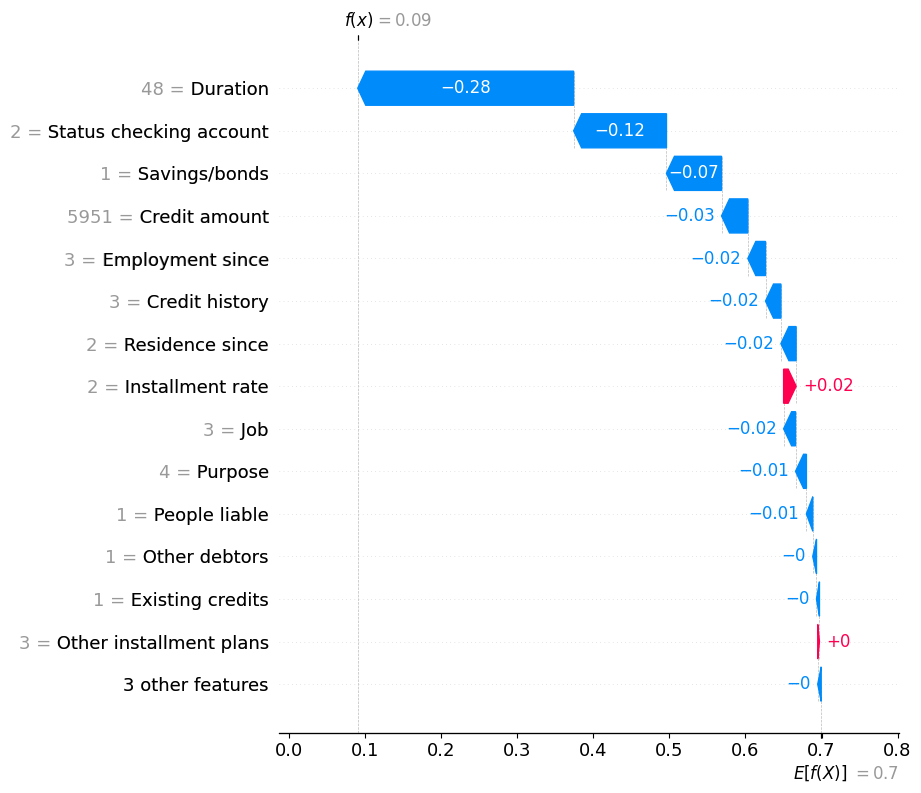

In [14]:
# SHAP waterfall plot for the first rejected application
shap_local_explanation = Explanation(
    values=shap_values[1][i],
    base_values=shap_explainer.expected_value[1],
    feature_names=feature_names,
    data=X[i]
)
shap.plots.waterfall(shap_local_explanation, max_display=15)

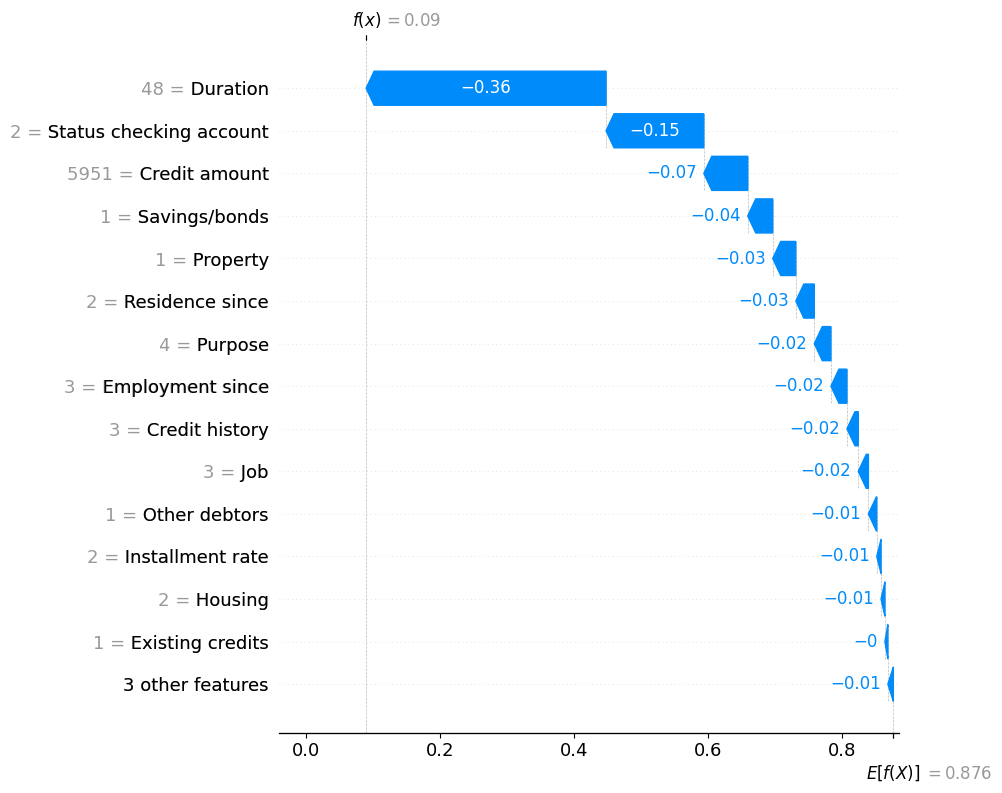

In [15]:
# CFSHAP waterfall plot for the first rejected application

# NOTE: Differently from shap, cfshap explanations have a base value for each query instance because the background distribution 
# used to compute the explanation is not static.
base_values = np.array([model.predict_proba(X_background).mean(axis=0) for X_background in explanations.backgrounds])

cfshap_local_explanation = Explanation(
    values=explanations.values[i],
    base_values=base_values[i][1],
    feature_names=feature_names,
    data=X[i],
)
shap.plots.waterfall(cfshap_local_explanation, max_display=15)

### Evaluation through a recourse simulation

In [16]:
# trying to push this application into being approved

# the original application was indeed rejected
x = X[i].copy()
print("Original prediction:", model.predict([x])) 

# get the range of values for all features
feature_min = X.min(axis=0)
feature_max = X.max(axis=0)
# get the mean for all features
feature_mean = X[y == 1].mean(axis=0)

# 1. SHAP
x_shap = x.copy()
for j in top_3_shap:
    # if the SHAP value is negative then this feature contributes to rejection
    # but since SHAP does not indicate whether the feature should be increased/decreased
    # instead just bring it a little bit closer to the mean
    if shap_values[1][i][j] < 0:  
        x_shap[j] += 0.3 * (feature_mean[j] - x_shap[j])

# 2. CF-SHAP
x_cf = x.copy()
for j in top_3_cfshap:
    # scale the step size to the specific feature's range
    step = 0.3 * (feature_max[j] - feature_min[j])
    # use the trend (+1/-1) to change the feature's values in the direction that 
    # pushes the prediction more towards approval
    x_cf[j] += step * explanations.trends[i][j]

# re-run the model to get a new prediction
print("SHAP new prediction:", model.predict([x_shap]))
print("CF-SHAP new prediction:", model.predict([x_cf]))

Original prediction: [0]
SHAP new prediction: [0]
CF-SHAP new prediction: [1]


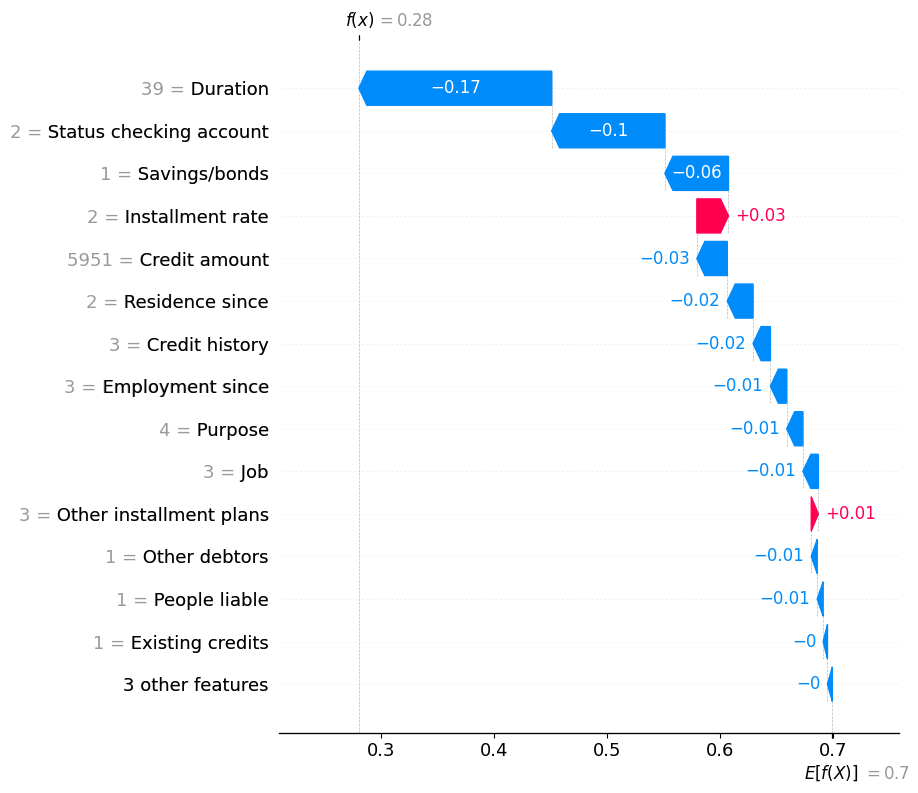

In [17]:
# SHAP: redo the waterfall plot
shap_local_exp = shap_explainer.shap_values(np.array([x_shap]))

shap_local_explanation = Explanation(
    values=shap_local_exp[1][0],                
    base_values=shap_explainer.expected_value[1],   
    feature_names=feature_names,
    data=x_shap
)

shap.plots.waterfall(shap_local_explanation, max_display=15)

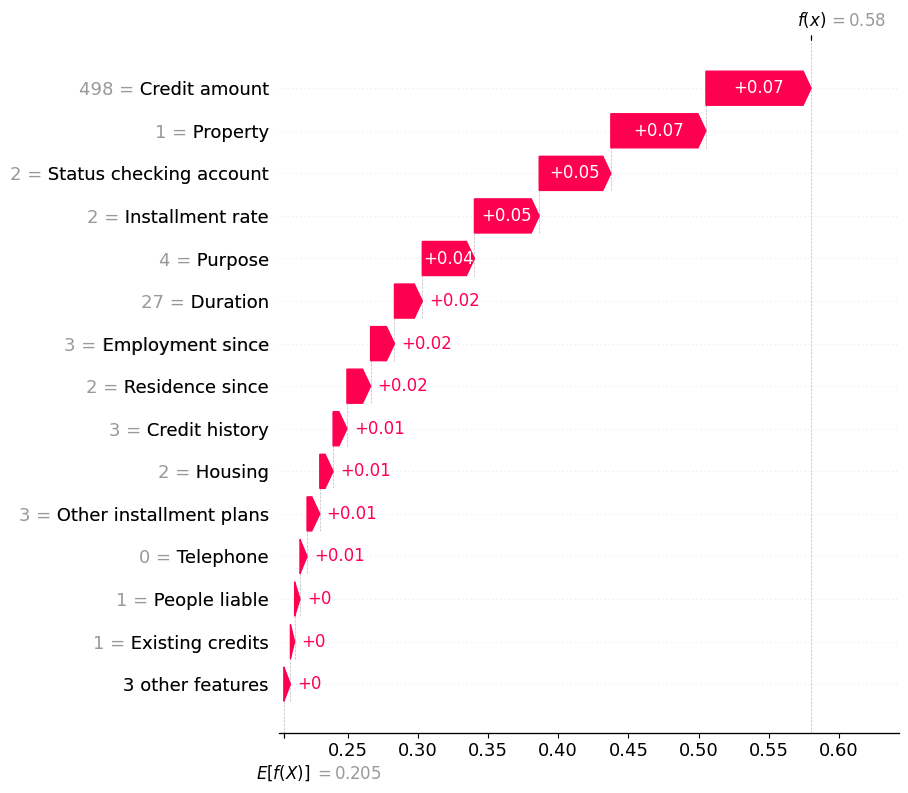

In [18]:
# CF-SHAP: redo the waterfall plot
cfshap_exp = cfshap_explainer(np.array([x_cf]))  
new_base_value = np.array([model.predict_proba(X_background).mean(axis=0) for X_background in cfshap_exp.backgrounds])

cfshap_local_explanation = Explanation(
    values=cfshap_exp.values[0],
    base_values=new_base_value[0][1],
    feature_names=feature_names,
    data=x_cf
)
shap.plots.waterfall(cfshap_local_explanation, max_display=15)